#Green Jobs στην Ελλάδα, Γερμανια, Γαλλία, Σουηδία, Ρουμανία, Τσεχία, Πολωνία, Ισπανία και Ιταλία

#Πρασινα Επαγγέλματα Γερμανία (DE)

Germany filtering with green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_germany_green_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

LOCATION_CODE = ["DE"]
OCCUPATION_IDS = green_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=DE and occupation_ids (OR logic)
    against the full list of green occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [DE]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} green occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['DE'], occupation_ids=(152 green occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(



Page 1 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


...


Page 224 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(



Page 224 attempt 2/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 10s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [DE]:  82%|████████▏ | 22400/27232 [2:28:44<1:42:59,  1.28s/job, pages=224]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [DE]:  83%|████████▎ | 22500/27232 [2:29:03<1:15:07,  1.05job/s, pages=225]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Ad

Total jobs collected: 27232
Saved job data to skillab_jobs_germany_green_occupations.json


#Πρασινα Επαγγέλματα στην Ελλάδα (EL)

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_greece_green_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

LOCATION_CODE = ["EL"]
OCCUPATION_IDS = green_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=EL and occupation_ids (OR logic)
    against the full list of green occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [EL]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} green occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['EL'], occupation_ids=(152 green occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [EL]:   2%|▏         | 100/4247 [00:00<00:00, 1072712.02job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [EL]:   5%|▍         | 200/4247 [01:02<21:12,  3.18job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certific

Total jobs collected: 4247
Saved job data to skillab_jobs_greece_green_occupations.json


#Πράσινα Επαγγέλματα Γαλλία (FR)

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_franche_green_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

LOCATION_CODE = ["FR"]
OCCUPATION_IDS = green_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=FR and occupation_ids (OR logic)
    against the full list of green occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [FR]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} green occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['FR'], occupation_ids=(152 green occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [FR]:   0%|          | 100/45072 [00:00<00:00, 2107690.45job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [FR]:   0%|          | 200/45072 [00:04<16:52, 44.33job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certif

Total jobs collected: 45072
Saved job data to skillab_jobs_franche_green_occupations.json


#Πράσινα Επαγγέλματα Σουηδία (SE)

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_sweden_green_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

LOCATION_CODE = ["SE"]
OCCUPATION_IDS = green_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=SE and occupation_ids (OR logic)
    against the full list of green occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [SE]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} green occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['SE'], occupation_ids=(152 green occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [SE]:   0%|          | 100/49058 [00:00<00:00, 1536375.09job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [SE]:   0%|          | 200/49058 [00:17<1:11:13, 11.43job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding cert


Page 10 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


...


Page 410 attempt 4/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 20s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(



Page 410 attempt 5/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 25s...



Giving up on page 410 after 5 attempts.
Total jobs collected: 40900


Saved job data to skillab_jobs_sweden_green_occupations.json


#Οπτικοποίση Αποτελεσμάτων Plots

{'Greece': 4247, 'Germany': 27232, 'France': 45072, 'Sweden': 40900}


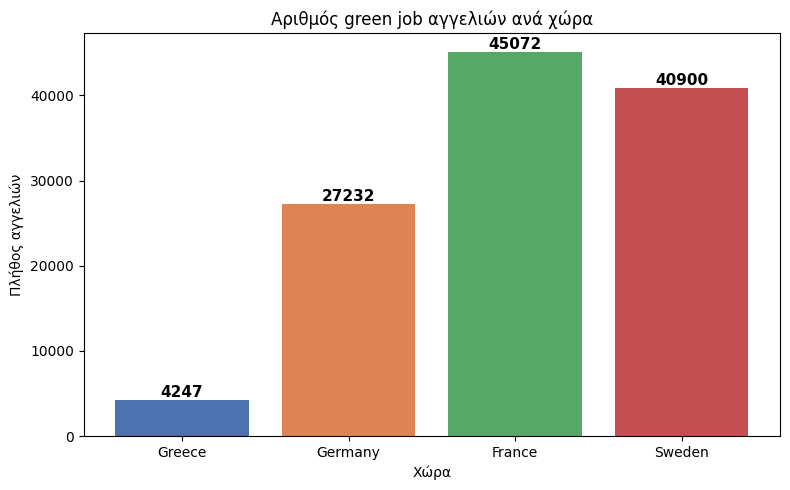

In [ ]:
import json
import matplotlib.pyplot as plt

files_by_country = {
    "Greece": "skillab_jobs_greece_green_occupations.json",
    "Germany": "skillab_jobs_germany_green_occupations.json",
    "France": "skillab_jobs_france_green_occupations.json",
    "Sweden": "skillab_jobs_sweden_green_occupations.json",
}

job_counts = {}
for country, filename in files_by_country.items():
    try:
        with open(filename, "r", encoding="utf-8") as f:
            jobs = json.load(f)
        job_counts[country] = len(jobs)
    except FileNotFoundError:
        print(f" Δεν βρέθηκε το αρχείο: {filename}")
        job_counts[country] = 0

print(job_counts)

countries = list(job_counts.keys())
counts = list(job_counts.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(countries, counts, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.title("Αριθμός green job αγγελιών ανά χώρα")
plt.ylabel("Πλήθος αγγελιών")
plt.xlabel("Χώρα")
plt.tight_layout()
plt.show()

#Πρασινα Επαγγέλματα Τσεχία (CZ)

Czechia filtering with green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_czechia_green_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

LOCATION_CODE = ["CZ"]
OCCUPATION_IDS = green_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=CZ and occupation_ids (OR logic)
    against the full list of green occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [CZ]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} green occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['CZ'], occupation_ids=(152 green occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [CZ]:  36%|███▋      | 100/274 [00:00<00:00, 961996.33job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [CZ]:  73%|███████▎  | 200/274 [00:40<00:14,  4.94job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate

Total jobs collected: 274
Saved job data to skillab_jobs_czechia_green_occupations.json


Czechia filtering with green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_czechia_green_skills.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 300     # μεγαλύτερο timeout, όπως είδαμε ότι χρειάζεται
MAX_RETRIES = 3
RETRY_BACKOFF = 15
MAX_JOBS = None


# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")

# Προσπάθησε πρώτα τη στήλη 'conceptUri' (όπως στο occupations csv).
# Αν δεν υπάρχει, δοκίμασε άλλες πιθανές ονομασίες στήλης.
uri_column = None
for candidate in ["conceptUri", "skillUri", "uri", "id"]:
    if candidate in green_skills_df.columns:
        uri_column = candidate
        break

if uri_column is None:
    raise ValueError(
        f"Δεν βρέθηκε αναγνωρίσιμη στήλη URI. Διαθέσιμες στήλες: {list(green_skills_df.columns)}"
    )

green_skill_uris = green_skills_df[uri_column].dropna().unique().tolist()
print(f"Επίσημα green skill URIs (στήλη '{uri_column}'): {len(green_skill_uris)}")

LOCATION_CODE = ["CZ"]
SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=CZ και skill_ids (OR logic)
    έναντι της πλήρους λίστας green skill URIs."""
    request_data = {
        "location_code": LOCATION_CODE,
        "skill_ids": SKILL_IDS,
        "skill_ids_logic": SKILL_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [CZ]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green skill URIs (στήλη 'conceptUri'): 629
Authenticating...
Token acquired.

Fetching /api/jobs
   filters: location_code=['CZ'], skill_ids=(629 green skill URIs, logic=or)


Total jobs collected: 377
Saved job data to skillab_jobs_czechia_green_skills.json


#Πρασινα Επαγγέλματα Ρουμανία (RO)

Συνολικό πλήθος εγγραφών Jobs στον tracker για την Ρουμανία (RO)

In [ ]:
import requests
import json
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"
REQUEST_TIMEOUT = 120


def get_token():
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def check_country_jobs(headers, code, page_size=1):
    """Ζητάει jobs ΜΟΝΟ με location_code filter, χωρίς occupation filter,
    και επιστρέφει το συνολικό count που δίνει το API (χωρίς να τραβήξει όλα τα δεδομένα)."""
    request_data = {"location_code": [code]}
    try:
        response = requests.post(
            f"{API_BASE_URL}/jobs",
            params={"page": 1, "page_size": page_size},
            headers=headers,
            data=request_data,
            verify=False,
            timeout=REQUEST_TIMEOUT
        )
        if response.status_code == 200:
            data = response.json()
            return data.get("count", "άγνωστο (δεν υπάρχει 'count' στο response)")
        else:
            return f"HTTP {response.status_code}: {response.text[:200]}"
    except requests.exceptions.RequestException as e:
        return f"Σφάλμα σύνδεσης: {e}"


token = get_token()
headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

# Δοκίμασε διάφορους πιθανούς κωδικούς για Ρουμανία + ένα γνωστό working (EL) για σύγκριση
candidates = ["EL", "RO", "ROU", "Romania", "ro"]

print("Έλεγχος συνολικών jobs ανά κωδικό χώρας (ΧΩΡΙΣ occupation filter):")
print("=" * 70)
for code in candidates:
    result = check_country_jobs(headers, code)
    print(f"  location_code = {code!r:15} → count = {result}")

Έλεγχος συνολικών jobs ανά κωδικό χώρας (ΧΩΡΙΣ occupation filter):
  location_code = 'EL'            → count = 91670
  location_code = 'RO'            → count = 16135
  location_code = 'ROU'           → count = 0
  location_code = 'Romania'       → count = 0
  location_code = 'ro'            → count = 0


Romania filtering with green occupations

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_romania_green_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 300
MAX_RETRIES = 3
RETRY_BACKOFF = 10
MAX_JOBS = None


# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

LOCATION_CODE = ["RO"]
OCCUPATION_IDS = green_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=RO and occupation_ids (OR logic)
    against the full list of green occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [RO]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} green occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

Fetching /api/jobs
   filters: location_code=['RO'], occupation_ids=(152 green occupation URIs, logic=or)


Total jobs collected: 0
Saved job data to skillab_jobs_romania_green_occupations.json


Romania filtering with green skills

In [ ]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_romania_green_skills.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 300     # μεγαλύτερο timeout, όπως είδαμε ότι χρειάζεται
MAX_RETRIES = 3
RETRY_BACKOFF = 15
MAX_JOBS = None


# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")

# Προσπάθησε πρώτα τη στήλη 'conceptUri' (όπως στο occupations csv).
# Αν δεν υπάρχει, δοκίμασε άλλες πιθανές ονομασίες στήλης.
uri_column = None
for candidate in ["conceptUri", "skillUri", "uri", "id"]:
    if candidate in green_skills_df.columns:
        uri_column = candidate
        break

if uri_column is None:
    raise ValueError(
        f"Δεν βρέθηκε αναγνωρίσιμη στήλη URI. Διαθέσιμες στήλες: {list(green_skills_df.columns)}"
    )

green_skill_uris = green_skills_df[uri_column].dropna().unique().tolist()
print(f"Επίσημα green skill URIs (στήλη '{uri_column}'): {len(green_skill_uris)}")

LOCATION_CODE = ["RO"]
SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=RO και skill_ids (OR logic)
    έναντι της πλήρους λίστας green skill URIs."""
    request_data = {
        "location_code": LOCATION_CODE,
        "skill_ids": SKILL_IDS,
        "skill_ids_logic": SKILL_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [RO]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green skill URIs (στήλη 'conceptUri'): 629
Authenticating...
Token acquired.

Fetching /api/jobs
   filters: location_code=['RO'], skill_ids=(629 green skill URIs, logic=or)


Total jobs collected: 76
Saved job data to skillab_jobs_romania_green_skills.json


#Plots με τα green jobs στις 6 χωρες

Green jobs ανά χώρα: {'Greece': 4247, 'Germany': 27232, 'France': 45072, 'Sweden': 40900, 'Romania': 76, 'Czechia': 377}


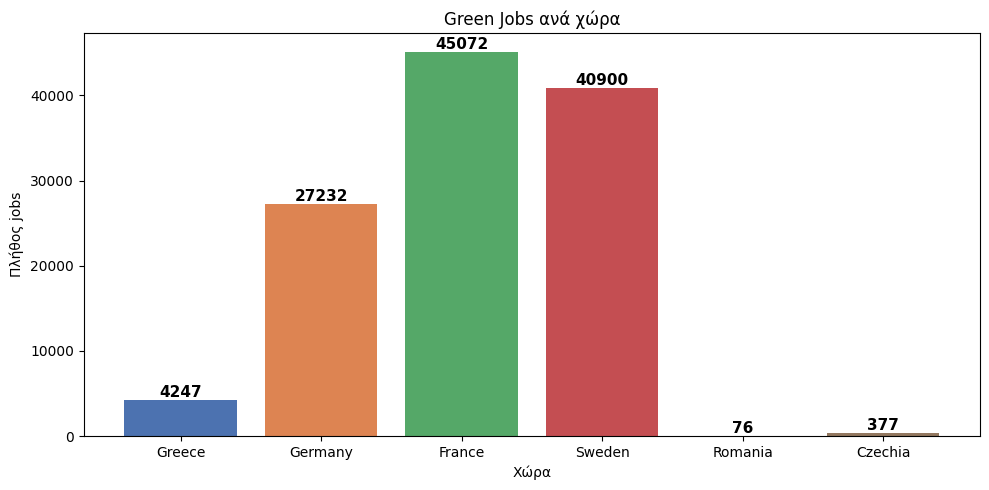

In [ ]:
import json
import matplotlib.pyplot as plt

# ── Αρχεία ανά χώρα ──────────────────────────────────────────────────────
# Σημείωση: Ελλάδα/Γερμανία/Γαλλία/Σουηδία → φιλτράρισμα με occupation_ids
#           Ρουμανία/Τσεχία               → φιλτράρισμα με skill_ids
job_files = {
    "Greece":  "skillab_jobs_greece_green_occupations.json",
    "Germany": "skillab_jobs_germany_green_occupations.json",
    "France":  "skillab_jobs_france_green_occupations.json",
    "Sweden":  "skillab_jobs_sweden_green_occupations.json",
    "Romania": "skillab_jobs_romania_green_skills.json",
    "Czechia": "skillab_jobs_czechia_green_skills.json",
}


def load_counts(files_dict):
    counts = {}
    for country, filename in files_dict.items():
        try:
            with open(filename, "r", encoding="utf-8") as f:
                jobs = json.load(f)
            counts[country] = len(jobs)
        except FileNotFoundError:
            print(f"⚠️  Δεν βρέθηκε το αρχείο: {filename}")
            counts[country] = 0
    return counts


job_counts = load_counts(job_files)

print("Green jobs ανά χώρα:", job_counts)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

# ── Διάγραμμα: Green Jobs ανά χώρα ─────────────────────────────────────────
plt.figure(figsize=(10, 5))
countries = list(job_counts.keys())
counts = list(job_counts.values())
bars = plt.bar(countries, counts, color=colors)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
              ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.title("Green Jobs ανά χώρα")
plt.ylabel("Πλήθος jobs")
plt.xlabel("Χώρα")
plt.tight_layout()
plt.show()

#Poland

jobs poland filtering with green occupations

In [2]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_poland_green_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

LOCATION_CODE = ["PL"]
OCCUPATION_IDS = green_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=PL and occupation_ids (OR logic)
    against the full list of green occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [PL]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} green occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Token acquired.

Fetching /api/jobs
   filters: location_code=['PL'], occupation_ids=(152 green occupation URIs, logic=or)


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(



Page 1 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [PL]:  28%|██▊       | 100/353 [00:00<00:00, 1015569.98job/s, pages=1]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Fetching jobs [PL]:  57%|█████▋    | 200/353 [01:12<00:55,  2.75job/s, pages=2]/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'skillab-tracker.csd.auth.gr'. Adding certificat

Total jobs collected: 353
Saved job data to skillab_jobs_poland_green_occupations.json


Poland filtering with green skills

In [3]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_poland_green_skills.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 300     # μεγαλύτερο timeout, όπως είδαμε ότι χρειάζεται
MAX_RETRIES = 3
RETRY_BACKOFF = 15
MAX_JOBS = None


# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")

# Προσπάθησε πρώτα τη στήλη 'conceptUri' (όπως στο occupations csv).
# Αν δεν υπάρχει, δοκίμασε άλλες πιθανές ονομασίες στήλης.
uri_column = None
for candidate in ["conceptUri", "skillUri", "uri", "id"]:
    if candidate in green_skills_df.columns:
        uri_column = candidate
        break

if uri_column is None:
    raise ValueError(
        f"Δεν βρέθηκε αναγνωρίσιμη στήλη URI. Διαθέσιμες στήλες: {list(green_skills_df.columns)}"
    )

green_skill_uris = green_skills_df[uri_column].dropna().unique().tolist()
print(f"Επίσημα green skill URIs (στήλη '{uri_column}'): {len(green_skill_uris)}")

LOCATION_CODE = ["PL"]
SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=PL και skill_ids (OR logic)
    έναντι της πλήρους λίστας green skill URIs."""
    request_data = {
        "location_code": LOCATION_CODE,
        "skill_ids": SKILL_IDS,
        "skill_ids_logic": SKILL_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [PL]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green skill URIs (στήλη 'conceptUri'): 629
Authenticating...
Token acquired.

Fetching /api/jobs
   filters: location_code=['PL'], skill_ids=(629 green skill URIs, logic=or)


Total jobs collected: 2299
Saved job data to skillab_jobs_poland_green_skills.json


#Spain

jobs spain filtering with green occupations

In [4]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_spain_green_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

LOCATION_CODE = ["ES"]
OCCUPATION_IDS = green_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=ES and occupation_ids (OR logic)
    against the full list of green occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [ES]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} green occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

Fetching /api/jobs
   filters: location_code=['ES'], occupation_ids=(152 green occupation URIs, logic=or)

Page 1 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


Total jobs collected: 769
Saved job data to skillab_jobs_spain_green_occupations.json


jobs spain filtering with green skills

In [5]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_spain_green_skills.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 300     # μεγαλύτερο timeout, όπως είδαμε ότι χρειάζεται
MAX_RETRIES = 3
RETRY_BACKOFF = 15
MAX_JOBS = None


# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")

# Προσπάθησε πρώτα τη στήλη 'conceptUri' (όπως στο occupations csv).
# Αν δεν υπάρχει, δοκίμασε άλλες πιθανές ονομασίες στήλης.
uri_column = None
for candidate in ["conceptUri", "skillUri", "uri", "id"]:
    if candidate in green_skills_df.columns:
        uri_column = candidate
        break

if uri_column is None:
    raise ValueError(
        f"Δεν βρέθηκε αναγνωρίσιμη στήλη URI. Διαθέσιμες στήλες: {list(green_skills_df.columns)}"
    )

green_skill_uris = green_skills_df[uri_column].dropna().unique().tolist()
print(f"Επίσημα green skill URIs (στήλη '{uri_column}'): {len(green_skill_uris)}")

LOCATION_CODE = ["ES"]
SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=ES και skill_ids (OR logic)
    έναντι της πλήρους λίστας green skill URIs."""
    request_data = {
        "location_code": LOCATION_CODE,
        "skill_ids": SKILL_IDS,
        "skill_ids_logic": SKILL_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [ES]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green skill URIs (στήλη 'conceptUri'): 629
Authenticating...
Token acquired.

Fetching /api/jobs
   filters: location_code=['ES'], skill_ids=(629 green skill URIs, logic=or)


Total jobs collected: 871
Saved job data to skillab_jobs_spain_green_skills.json


#Italy

jobs italy filtering with green occupations

In [6]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd


API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_italy_green_occupations.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 120
MAX_RETRIES = 5
RETRY_BACKOFF = 5
MAX_JOBS = None


# Φόρτωση της λίστας green occupations (ESCO)
green_occ_df = pd.read_csv("/content/highly_green_occupations.csv")
green_occupation_uris = green_occ_df["conceptUri"].dropna().unique().tolist()
print(f"Επίσημα green occupation URIs: {len(green_occupation_uris)}")

LOCATION_CODE = ["IT"]
OCCUPATION_IDS = green_occupation_uris
OCCUPATION_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = requests.post(
        f"{API_BASE_URL}/login",
        json={"username": USERNAME, "password": PASSWORD},
        headers={"accept": "application/json", "Content-Type": "application/json"},
        verify=False,
        timeout=REQUEST_TIMEOUT
    )
    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=IT and occupation_ids (OR logic)
    against the full list of green occupation URIs (single request, no chunking)."""
    request_data = {
        "location_code": LOCATION_CODE,
        "occupation_ids": OCCUPATION_IDS,
        "occupation_ids_logic": OCCUPATION_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\nPage {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\nGiving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\nHTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [IT]", unit="job", leave=False)

            if not items:
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\nReached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\nFetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, occupation_ids=({len(OCCUPATION_IDS)} green occupation URIs, logic={OCCUPATION_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"Saved job data to {OUTPUT_FILE}")

Επίσημα green occupation URIs: 152
Authenticating...
Token acquired.

Fetching /api/jobs
   filters: location_code=['IT'], occupation_ids=(152 green occupation URIs, logic=or)

Page 1 attempt 1/5 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=120)); retrying in 5s...


Total jobs collected: 200
Saved job data to skillab_jobs_italy_green_occupations.json


jobs italy filtering with green skills

In [7]:
import requests
import json
import urllib3
from time import sleep
from tqdm import tqdm
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

API_BASE_URL = "https://skillab-tracker.csd.auth.gr/api"
USERNAME = "skillab_staff"
PASSWORD = "skillroadtrip00"

OUTPUT_FILE = "skillab_jobs_italy_green_skills.json"
PAGE_SIZE = 100
REQUEST_TIMEOUT = 300     # μεγαλύτερο timeout, όπως είδαμε ότι χρειάζεται
MAX_RETRIES = 3
RETRY_BACKOFF = 15
MAX_JOBS = None  # βάλε έναν αριθμό αν θες cap, None = χωρίς όριο

# ── Filters ─────────────────────────────────────────────────────────────
LOCATION_CODE = ["IT"]

# Φόρτωση της λίστας green skills (ESCO)
green_skills_df = pd.read_csv("/content/greenSkillsCollection_en.csv")

# Προσπάθησε πρώτα τη στήλη 'conceptUri' (όπως στο occupations csv).
# Αν δεν υπάρχει, δοκίμασε άλλες πιθανές ονομασίες στήλης.
uri_column = None
for candidate in ["conceptUri", "skillUri", "uri", "id"]:
    if candidate in green_skills_df.columns:
        uri_column = candidate
        break

if uri_column is None:
    raise ValueError(
        f"Δεν βρέθηκε αναγνωρίσιμη στήλη URI. Διαθέσιμες στήλες: {list(green_skills_df.columns)}"
    )

green_skill_uris = green_skills_df[uri_column].dropna().unique().tolist()
print(f"Επίσημα green skill URIs (στήλη '{uri_column}'): {len(green_skill_uris)}")

SKILL_IDS = green_skill_uris
SKILL_IDS_LOGIC = "or"


def get_token():
    print("Authenticating...")
    response = None
    last_error = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = requests.post(
                f"{API_BASE_URL}/login",
                json={"username": USERNAME, "password": PASSWORD},
                headers={"accept": "application/json", "Content-Type": "application/json"},
                verify=False,
                timeout=REQUEST_TIMEOUT
            )
            break
        except requests.exceptions.RequestException as e:
            last_error = e
            wait = RETRY_BACKOFF * attempt
            print(f"⚠️  Login attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
            sleep(wait)

    if response is None:
        raise RuntimeError(f"Failed to authenticate after {MAX_RETRIES} attempts: {last_error}")

    if response.status_code == 200:
        print("Token acquired.")
        return response.text.replace('"', "")
    raise RuntimeError(f"Failed to authenticate: {response.status_code} - {response.text}")


def fetch_all_jobs(headers):
    """Paginated fetch of /api/jobs, filtered by location_code=IT και skill_ids (OR logic)
    έναντι της πλήρους λίστας green skill URIs."""
    request_data = {
        "location_code": LOCATION_CODE,
        "skill_ids": SKILL_IDS,
        "skill_ids_logic": SKILL_IDS_LOGIC,
    }

    collected = []
    page = 1
    total_count = None
    pbar = None

    try:
        while True:
            response = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    response = requests.post(
                        f"{API_BASE_URL}/jobs",
                        params={"page": page, "page_size": PAGE_SIZE},
                        headers=headers,
                        data=request_data,
                        verify=False,
                        timeout=REQUEST_TIMEOUT
                    )
                    break
                except requests.exceptions.RequestException as e:
                    wait = RETRY_BACKOFF * attempt
                    print(f"\n⚠️  Page {page} attempt {attempt}/{MAX_RETRIES} failed ({e}); retrying in {wait}s...")
                    sleep(wait)

            if response is None:
                print(f"\n❌ Giving up on page {page} after {MAX_RETRIES} attempts.")
                break

            if response.status_code != 200:
                print(f"\n❌ HTTP {response.status_code} on page {page}: {response.text[:500]}")
                break

            page_data = response.json()
            items = page_data.get("items", [])
            total_count = page_data.get("count", total_count)

            if pbar is None:
                pbar = tqdm(total=total_count, desc="Fetching jobs [Italy]", unit="job")

            if not items:
                print("✅ Empty page — no more results.")
                break

            collected.extend(items)
            pbar.update(len(items))
            pbar.set_postfix(pages=page)

            if total_count is not None and len(collected) >= total_count:
                break

            if MAX_JOBS and len(collected) >= MAX_JOBS:
                print(f"\n🛑 Reached cap of {MAX_JOBS} jobs — stopping early.")
                break

            page += 1
            sleep(0.3)
    finally:
        if pbar is not None:
            pbar.close()

    return collected


token = get_token()

headers = {
    "accept": "application/json",
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {token}"
}

print("\n📡 Fetching /api/jobs")
print(f"   filters: location_code={LOCATION_CODE}, skill_ids=({len(SKILL_IDS)} green skill URIs, logic={SKILL_IDS_LOGIC})")
print("=" * 60)

all_jobs = fetch_all_jobs(headers)

print("=" * 60)
print(f"✅ Total jobs collected: {len(all_jobs)}")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_jobs, f, indent=4, ensure_ascii=False)

print(f"✅ Saved job data to {OUTPUT_FILE}")


Επίσημα green skill URIs (στήλη 'conceptUri'): 629
Authenticating...
Token acquired.

📡 Fetching /api/jobs
   filters: location_code=['IT'], skill_ids=(629 green skill URIs, logic=or)


Fetching jobs [Italy]:  22%|██▏       | 4600/20499 [2:07:02<10:39:44,  2.41s/job, pages=46]


⚠️  Page 47 attempt 1/3 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=300)); retrying in 15s...


Fetching jobs [Italy]:  23%|██▎       | 4800/20499 [2:20:11<13:21:07,  3.06s/job, pages=48]


⚠️  Page 49 attempt 1/3 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=300)); retrying in 15s...

⚠️  Page 49 attempt 2/3 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=300)); retrying in 30s...

⚠️  Page 49 attempt 3/3 failed (HTTPSConnectionPool(host='skillab-tracker.csd.auth.gr', port=443): Read timed out. (read timeout=300)); retrying in 45s...


Fetching jobs [Italy]:  23%|██▎       | 4800/20499 [2:36:43<8:32:36,  1.96s/job, pages=48] 


❌ Giving up on page 49 after 3 attempts.
✅ Total jobs collected: 4800


✅ Saved job data to skillab_jobs_italy_green_skills.json


#Green Skills Vs Green Occ for the finals job datasets

In [8]:
import json
import pandas as pd

# ============================================================
# 1. Paths αρχείων (άλλαξέ τα αν χρειάζεται)
# ============================================================
path_jobs = "skillab_jobs_poland_green_skills.json"
path_green_skills_csv = "greenSkillsCollection_en.csv"
path_output = "skillab_jobs_poland_green_skills_50plus.json"

THRESHOLD = 0.5  # 50%

# ============================================================
# 2. Loader για το jobs JSON (αντέχει και σε JSON / JSON Lines)
# ============================================================
def load_records(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    try:
        data = json.loads(content)
        if isinstance(data, dict):
            for value in data.values():
                if isinstance(value, list):
                    return value
            return [data]
        return data
    except json.JSONDecodeError:
        pass

    records = []
    bad_lines = 0
    for line in content.splitlines():
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]", "{", "}"):
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1
    if bad_lines:
        print(f"⚠️  {path}: αγνοήθηκαν {bad_lines} γραμμές με σφάλμα JSON.")
    if not records:
        raise ValueError(f"Δεν βρέθηκαν έγκυρες εγγραφές στο {path}")
    return records

jobs_records = load_records(path_jobs)
print(f"Πλήθος εγγραφών (jobs) στο dataset: {len(jobs_records)}")

# ============================================================
# 3. Φόρτωση της λίστας ESCO green skills από το CSV
#    Το CSV της ESCO συνήθως έχει στήλη 'conceptUri' με τα URIs.
#    Το κάνουμε robust: ψάχνουμε αυτόματα τη σωστή στήλη.
# ============================================================
green_df = pd.read_csv(path_green_skills_csv)

uri_col = None
for col in green_df.columns:
    sample_vals = green_df[col].dropna().astype(str).head(20)
    if sample_vals.str.startswith("http://data.europa.eu/esco/skill/").any():
        uri_col = col
        break

if uri_col is None:
    raise ValueError(
        f"Δεν βρέθηκε στήλη με ESCO skill URIs στο CSV. "
        f"Διαθέσιμες στήλες: {list(green_df.columns)}"
    )

green_skills_uris = set(green_df[uri_col].dropna().astype(str).str.strip())
print(f"Στήλη URIs που εντοπίστηκε: '{uri_col}'")
print(f"Πλήθος μοναδικών ESCO green skills: {len(green_skills_uris)}")

# ============================================================
# 4. Υπολογισμός ποσοστού green skills ανά εγγραφή
# ============================================================
def green_skill_ratio(record):
    skills = record.get("skills") or []
    skills = [s.strip() if isinstance(s, str) else s for s in skills]
    total = len(skills)
    if total == 0:
        return 0.0, 0, 0
    green_count = sum(1 for s in skills if s in green_skills_uris)
    return green_count / total, green_count, total

results = []
for rec in jobs_records:
    ratio, green_count, total = green_skill_ratio(rec)
    results.append({
        "id": rec.get("id"),
        "source_id": rec.get("source_id"),
        "location": rec.get("location"),
        "total_skills": total,
        "green_skills_count": green_count,
        "green_ratio": ratio,
        "record": rec,  # κρατάμε ολόκληρη την αρχική εγγραφή
    })

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "record"} for r in results
])

print("\n--- Στατιστικά ποσοστού πράσινων skills ανά εγγραφή ---")
print(df_results["green_ratio"].describe())

# ============================================================
# 5. Φιλτράρισμα εγγραφών με ποσοστό >= 50%
# ============================================================
filtered = [r["record"] for r in results if r["green_ratio"] >= THRESHOLD]

print(f"\nΕγγραφές με ποσοστό πράσινων skills >= {int(THRESHOLD*100)}%: {len(filtered)} "
      f"από σύνολο {len(jobs_records)} "
      f"({len(filtered)/len(jobs_records)*100:.2f}%)")

# ============================================================
# 6. Αποθήκευση αποτελέσματος σε νέο JSON αρχείο
# ============================================================
with open(path_output, "w", encoding="utf-8") as f:
    json.dump(filtered, f, ensure_ascii=False, indent=2)

print(f"\n✅ Αποθηκεύτηκε το αρχείο: {path_output}")

Πλήθος εγγραφών (jobs) στο dataset: 2299
Στήλη URIs που εντοπίστηκε: 'conceptUri'
Πλήθος μοναδικών ESCO green skills: 629

--- Στατιστικά ποσοστού πράσινων skills ανά εγγραφή ---
count    2299.000000
mean        0.141714
std         0.225297
min         0.015625
25%         0.023810
50%         0.030303
75%         0.166667
max         1.000000
Name: green_ratio, dtype: float64

Εγγραφές με ποσοστό πράσινων skills >= 50%: 231 από σύνολο 2299 (10.05%)

✅ Αποθηκεύτηκε το αρχείο: skillab_jobs_poland_green_skills_50plus.json


In [9]:
import json
import pandas as pd

# ============================================================
# 1. Paths αρχείων (άλλαξέ τα αν χρειάζεται)
# ============================================================
path_jobs = "skillab_jobs_poland_green_occupations.json"
path_green_occ_csv = "highly_green_occupations.csv"
path_output = "skillab_jobs_poland_green_occupations_50plus.json"

THRESHOLD = 0.5  # 50%

# ============================================================
# 2. Loader για το jobs JSON (αντέχει και σε JSON / JSON Lines)
# ============================================================
def load_records(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    try:
        data = json.loads(content)
        if isinstance(data, dict):
            for value in data.values():
                if isinstance(value, list):
                    return value
            return [data]
        return data
    except json.JSONDecodeError:
        pass

    records = []
    bad_lines = 0
    for line in content.splitlines():
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]", "{", "}"):
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1
    if bad_lines:
        print(f"⚠️  {path}: αγνοήθηκαν {bad_lines} γραμμές με σφάλμα JSON.")
    if not records:
        raise ValueError(f"Δεν βρέθηκαν έγκυρες εγγραφές στο {path}")
    return records

jobs_records = load_records(path_jobs)
print(f"Πλήθος εγγραφών (jobs) στο dataset: {len(jobs_records)}")

# ============================================================
# 3. Φόρτωση της λίστας green occupations από το CSV
#    Ψάχνουμε αυτόματα τη στήλη με ESCO occupation/isco URIs
#    (π.χ. http://data.europa.eu/esco/occupation/... ή .../isco/...)
# ============================================================
green_df = pd.read_csv(path_green_occ_csv)

uri_col = None
for col in green_df.columns:
    sample_vals = green_df[col].dropna().astype(str).head(20)
    if sample_vals.str.startswith("http://data.europa.eu/esco/").any():
        uri_col = col
        break

if uri_col is None:
    raise ValueError(
        f"Δεν βρέθηκε στήλη με ESCO occupation URIs στο CSV. "
        f"Διαθέσιμες στήλες: {list(green_df.columns)}"
    )

green_occupations_uris = set(green_df[uri_col].dropna().astype(str).str.strip())
print(f"Στήλη URIs που εντοπίστηκε: '{uri_col}'")
print(f"Πλήθος μοναδικών green occupations: {len(green_occupations_uris)}")

# ============================================================
# 4. Υπολογισμός ποσοστού green occupations ανά εγγραφή
# ============================================================
def green_occupation_ratio(record):
    occupations = record.get("occupations") or []
    occupations = [o.strip() if isinstance(o, str) else o for o in occupations]
    total = len(occupations)
    if total == 0:
        return 0.0, 0, 0
    green_count = sum(1 for o in occupations if o in green_occupations_uris)
    return green_count / total, green_count, total

results = []
for rec in jobs_records:
    ratio, green_count, total = green_occupation_ratio(rec)
    results.append({
        "id": rec.get("id"),
        "source_id": rec.get("source_id"),
        "location": rec.get("location"),
        "total_occupations": total,
        "green_occupations_count": green_count,
        "green_ratio": ratio,
        "record": rec,  # κρατάμε ολόκληρη την αρχική εγγραφή
    })

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "record"} for r in results
])

print("\n--- Στατιστικά ποσοστού πράσινων occupations ανά εγγραφή ---")
print(df_results["green_ratio"].describe())

# ============================================================
# 5. Φιλτράρισμα εγγραφών με ποσοστό >= 50%
# ============================================================
filtered = [r["record"] for r in results if r["green_ratio"] >= THRESHOLD]

print(f"\nΕγγραφές με ποσοστό πράσινων occupations >= {int(THRESHOLD*100)}%: {len(filtered)} "
      f"από σύνολο {len(jobs_records)} "
      f"({len(filtered)/len(jobs_records)*100:.2f}%)")

# ============================================================
# 6. Αποθήκευση αποτελέσματος σε νέο JSON αρχείο
# ============================================================
with open(path_output, "w", encoding="utf-8") as f:
    json.dump(filtered, f, ensure_ascii=False, indent=2)

print(f"\n✅ Αποθηκεύτηκε το αρχείο: {path_output}")

Πλήθος εγγραφών (jobs) στο dataset: 353
Στήλη URIs που εντοπίστηκε: 'conceptUri'
Πλήθος μοναδικών green occupations: 152

--- Στατιστικά ποσοστού πράσινων occupations ανά εγγραφή ---
count    353.000000
mean       0.995751
std        0.045963
min        0.500000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: green_ratio, dtype: float64

Εγγραφές με ποσοστό πράσινων occupations >= 50%: 353 από σύνολο 353 (100.00%)

✅ Αποθηκεύτηκε το αρχείο: skillab_jobs_poland_green_occupations_50plus.json


In [10]:
import json
import pandas as pd

# ============================================================
# 1. Paths αρχείων (άλλαξέ τα αν χρειάζεται)
# ============================================================
path_jobs = "skillab_jobs_italy_green_skills.json"
path_green_skills_csv = "greenSkillsCollection_en.csv"
path_output = "skillab_jobs_italy_green_skills_50plus.json"

THRESHOLD = 0.5  # 50%

# ============================================================
# 2. Loader για το jobs JSON (αντέχει και σε JSON / JSON Lines)
# ============================================================
def load_records(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    try:
        data = json.loads(content)
        if isinstance(data, dict):
            for value in data.values():
                if isinstance(value, list):
                    return value
            return [data]
        return data
    except json.JSONDecodeError:
        pass

    records = []
    bad_lines = 0
    for line in content.splitlines():
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]", "{", "}"):
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1
    if bad_lines:
        print(f"⚠️  {path}: αγνοήθηκαν {bad_lines} γραμμές με σφάλμα JSON.")
    if not records:
        raise ValueError(f"Δεν βρέθηκαν έγκυρες εγγραφές στο {path}")
    return records

jobs_records = load_records(path_jobs)
print(f"Πλήθος εγγραφών (jobs) στο dataset: {len(jobs_records)}")

# ============================================================
# 3. Φόρτωση της λίστας ESCO green skills από το CSV
#    Το CSV της ESCO συνήθως έχει στήλη 'conceptUri' με τα URIs.
#    Το κάνουμε robust: ψάχνουμε αυτόματα τη σωστή στήλη.
# ============================================================
green_df = pd.read_csv(path_green_skills_csv)

uri_col = None
for col in green_df.columns:
    sample_vals = green_df[col].dropna().astype(str).head(20)
    if sample_vals.str.startswith("http://data.europa.eu/esco/skill/").any():
        uri_col = col
        break

if uri_col is None:
    raise ValueError(
        f"Δεν βρέθηκε στήλη με ESCO skill URIs στο CSV. "
        f"Διαθέσιμες στήλες: {list(green_df.columns)}"
    )

green_skills_uris = set(green_df[uri_col].dropna().astype(str).str.strip())
print(f"Στήλη URIs που εντοπίστηκε: '{uri_col}'")
print(f"Πλήθος μοναδικών ESCO green skills: {len(green_skills_uris)}")

# ============================================================
# 4. Υπολογισμός ποσοστού green skills ανά εγγραφή
# ============================================================
def green_skill_ratio(record):
    skills = record.get("skills") or []
    skills = [s.strip() if isinstance(s, str) else s for s in skills]
    total = len(skills)
    if total == 0:
        return 0.0, 0, 0
    green_count = sum(1 for s in skills if s in green_skills_uris)
    return green_count / total, green_count, total

results = []
for rec in jobs_records:
    ratio, green_count, total = green_skill_ratio(rec)
    results.append({
        "id": rec.get("id"),
        "source_id": rec.get("source_id"),
        "location": rec.get("location"),
        "total_skills": total,
        "green_skills_count": green_count,
        "green_ratio": ratio,
        "record": rec,  # κρατάμε ολόκληρη την αρχική εγγραφή
    })

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "record"} for r in results
])

print("\n--- Στατιστικά ποσοστού πράσινων skills ανά εγγραφή ---")
print(df_results["green_ratio"].describe())

# ============================================================
# 5. Φιλτράρισμα εγγραφών με ποσοστό >= 50%
# ============================================================
filtered = [r["record"] for r in results if r["green_ratio"] >= THRESHOLD]

print(f"\nΕγγραφές με ποσοστό πράσινων skills >= {int(THRESHOLD*100)}%: {len(filtered)} "
      f"από σύνολο {len(jobs_records)} "
      f"({len(filtered)/len(jobs_records)*100:.2f}%)")

# ============================================================
# 6. Αποθήκευση αποτελέσματος σε νέο JSON αρχείο
# ============================================================
with open(path_output, "w", encoding="utf-8") as f:
    json.dump(filtered, f, ensure_ascii=False, indent=2)

print(f"\n✅ Αποθηκεύτηκε το αρχείο: {path_output}")

Πλήθος εγγραφών (jobs) στο dataset: 4800
Στήλη URIs που εντοπίστηκε: 'conceptUri'
Πλήθος μοναδικών ESCO green skills: 629

--- Στατιστικά ποσοστού πράσινων skills ανά εγγραφή ---
count    4800.000000
mean        0.067721
std         0.079503
min         0.018868
25%         0.037037
50%         0.050000
75%         0.071429
max         1.000000
Name: green_ratio, dtype: float64

Εγγραφές με ποσοστό πράσινων skills >= 50%: 46 από σύνολο 4800 (0.96%)

✅ Αποθηκεύτηκε το αρχείο: skillab_jobs_italy_green_skills_50plus.json


In [11]:
import json
import pandas as pd

# ============================================================
# 1. Paths αρχείων (άλλαξέ τα αν χρειάζεται)
# ============================================================
path_jobs = "skillab_jobs_italy_green_occupations.json"
path_green_occ_csv = "highly_green_occupations.csv"
path_output = "skillab_jobs_italy_green_occupations_50plus.json"

THRESHOLD = 0.5  # 50%

# ============================================================
# 2. Loader για το jobs JSON (αντέχει και σε JSON / JSON Lines)
# ============================================================
def load_records(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    try:
        data = json.loads(content)
        if isinstance(data, dict):
            for value in data.values():
                if isinstance(value, list):
                    return value
            return [data]
        return data
    except json.JSONDecodeError:
        pass

    records = []
    bad_lines = 0
    for line in content.splitlines():
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]", "{", "}"):
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1
    if bad_lines:
        print(f"⚠️  {path}: αγνοήθηκαν {bad_lines} γραμμές με σφάλμα JSON.")
    if not records:
        raise ValueError(f"Δεν βρέθηκαν έγκυρες εγγραφές στο {path}")
    return records

jobs_records = load_records(path_jobs)
print(f"Πλήθος εγγραφών (jobs) στο dataset: {len(jobs_records)}")

# ============================================================
# 3. Φόρτωση της λίστας green occupations από το CSV
#    Ψάχνουμε αυτόματα τη στήλη με ESCO occupation/isco URIs
#    (π.χ. http://data.europa.eu/esco/occupation/... ή .../isco/...)
# ============================================================
green_df = pd.read_csv(path_green_occ_csv)

uri_col = None
for col in green_df.columns:
    sample_vals = green_df[col].dropna().astype(str).head(20)
    if sample_vals.str.startswith("http://data.europa.eu/esco/").any():
        uri_col = col
        break

if uri_col is None:
    raise ValueError(
        f"Δεν βρέθηκε στήλη με ESCO occupation URIs στο CSV. "
        f"Διαθέσιμες στήλες: {list(green_df.columns)}"
    )

green_occupations_uris = set(green_df[uri_col].dropna().astype(str).str.strip())
print(f"Στήλη URIs που εντοπίστηκε: '{uri_col}'")
print(f"Πλήθος μοναδικών green occupations: {len(green_occupations_uris)}")

# ============================================================
# 4. Υπολογισμός ποσοστού green occupations ανά εγγραφή
# ============================================================
def green_occupation_ratio(record):
    occupations = record.get("occupations") or []
    occupations = [o.strip() if isinstance(o, str) else o for o in occupations]
    total = len(occupations)
    if total == 0:
        return 0.0, 0, 0
    green_count = sum(1 for o in occupations if o in green_occupations_uris)
    return green_count / total, green_count, total

results = []
for rec in jobs_records:
    ratio, green_count, total = green_occupation_ratio(rec)
    results.append({
        "id": rec.get("id"),
        "source_id": rec.get("source_id"),
        "location": rec.get("location"),
        "total_occupations": total,
        "green_occupations_count": green_count,
        "green_ratio": ratio,
        "record": rec,  # κρατάμε ολόκληρη την αρχική εγγραφή
    })

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "record"} for r in results
])

print("\n--- Στατιστικά ποσοστού πράσινων occupations ανά εγγραφή ---")
print(df_results["green_ratio"].describe())

# ============================================================
# 5. Φιλτράρισμα εγγραφών με ποσοστό >= 50%
# ============================================================
filtered = [r["record"] for r in results if r["green_ratio"] >= THRESHOLD]

print(f"\nΕγγραφές με ποσοστό πράσινων occupations >= {int(THRESHOLD*100)}%: {len(filtered)} "
      f"από σύνολο {len(jobs_records)} "
      f"({len(filtered)/len(jobs_records)*100:.2f}%)")

# ============================================================
# 6. Αποθήκευση αποτελέσματος σε νέο JSON αρχείο
# ============================================================
with open(path_output, "w", encoding="utf-8") as f:
    json.dump(filtered, f, ensure_ascii=False, indent=2)

print(f"\n✅ Αποθηκεύτηκε το αρχείο: {path_output}")

Πλήθος εγγραφών (jobs) στο dataset: 200
Στήλη URIs που εντοπίστηκε: 'conceptUri'
Πλήθος μοναδικών green occupations: 152

--- Στατιστικά ποσοστού πράσινων occupations ανά εγγραφή ---
count    200.000000
mean       0.337917
std        0.125924
min        0.250000
25%        0.250000
50%        0.250000
75%        0.500000
max        1.000000
Name: green_ratio, dtype: float64

Εγγραφές με ποσοστό πράσινων occupations >= 50%: 62 από σύνολο 200 (31.00%)

✅ Αποθηκεύτηκε το αρχείο: skillab_jobs_italy_green_occupations_50plus.json


In [12]:
import json
import pandas as pd

# ============================================================
# 1. Paths αρχείων (άλλαξέ τα αν χρειάζεται)
# ============================================================
path_jobs = "skillab_jobs_spain_green_skills.json"
path_green_skills_csv = "greenSkillsCollection_en.csv"
path_output = "skillab_jobs_spain_green_skills_50plus.json"

THRESHOLD = 0.5  # 50%

# ============================================================
# 2. Loader για το jobs JSON (αντέχει και σε JSON / JSON Lines)
# ============================================================
def load_records(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    try:
        data = json.loads(content)
        if isinstance(data, dict):
            for value in data.values():
                if isinstance(value, list):
                    return value
            return [data]
        return data
    except json.JSONDecodeError:
        pass

    records = []
    bad_lines = 0
    for line in content.splitlines():
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]", "{", "}"):
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1
    if bad_lines:
        print(f"⚠️  {path}: αγνοήθηκαν {bad_lines} γραμμές με σφάλμα JSON.")
    if not records:
        raise ValueError(f"Δεν βρέθηκαν έγκυρες εγγραφές στο {path}")
    return records

jobs_records = load_records(path_jobs)
print(f"Πλήθος εγγραφών (jobs) στο dataset: {len(jobs_records)}")

# ============================================================
# 3. Φόρτωση της λίστας ESCO green skills από το CSV
#    Το CSV της ESCO συνήθως έχει στήλη 'conceptUri' με τα URIs.
#    Το κάνουμε robust: ψάχνουμε αυτόματα τη σωστή στήλη.
# ============================================================
green_df = pd.read_csv(path_green_skills_csv)

uri_col = None
for col in green_df.columns:
    sample_vals = green_df[col].dropna().astype(str).head(20)
    if sample_vals.str.startswith("http://data.europa.eu/esco/skill/").any():
        uri_col = col
        break

if uri_col is None:
    raise ValueError(
        f"Δεν βρέθηκε στήλη με ESCO skill URIs στο CSV. "
        f"Διαθέσιμες στήλες: {list(green_df.columns)}"
    )

green_skills_uris = set(green_df[uri_col].dropna().astype(str).str.strip())
print(f"Στήλη URIs που εντοπίστηκε: '{uri_col}'")
print(f"Πλήθος μοναδικών ESCO green skills: {len(green_skills_uris)}")

# ============================================================
# 4. Υπολογισμός ποσοστού green skills ανά εγγραφή
# ============================================================
def green_skill_ratio(record):
    skills = record.get("skills") or []
    skills = [s.strip() if isinstance(s, str) else s for s in skills]
    total = len(skills)
    if total == 0:
        return 0.0, 0, 0
    green_count = sum(1 for s in skills if s in green_skills_uris)
    return green_count / total, green_count, total

results = []
for rec in jobs_records:
    ratio, green_count, total = green_skill_ratio(rec)
    results.append({
        "id": rec.get("id"),
        "source_id": rec.get("source_id"),
        "location": rec.get("location"),
        "total_skills": total,
        "green_skills_count": green_count,
        "green_ratio": ratio,
        "record": rec,  # κρατάμε ολόκληρη την αρχική εγγραφή
    })

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "record"} for r in results
])

print("\n--- Στατιστικά ποσοστού πράσινων skills ανά εγγραφή ---")
print(df_results["green_ratio"].describe())

# ============================================================
# 5. Φιλτράρισμα εγγραφών με ποσοστό >= 50%
# ============================================================
filtered = [r["record"] for r in results if r["green_ratio"] >= THRESHOLD]

print(f"\nΕγγραφές με ποσοστό πράσινων skills >= {int(THRESHOLD*100)}%: {len(filtered)} "
      f"από σύνολο {len(jobs_records)} "
      f"({len(filtered)/len(jobs_records)*100:.2f}%)")

# ============================================================
# 6. Αποθήκευση αποτελέσματος σε νέο JSON αρχείο
# ============================================================
with open(path_output, "w", encoding="utf-8") as f:
    json.dump(filtered, f, ensure_ascii=False, indent=2)

print(f"\n✅ Αποθηκεύτηκε το αρχείο: {path_output}")

Πλήθος εγγραφών (jobs) στο dataset: 871
Στήλη URIs που εντοπίστηκε: 'conceptUri'
Πλήθος μοναδικών ESCO green skills: 629

--- Στατιστικά ποσοστού πράσινων skills ανά εγγραφή ---
count    871.000000
mean       0.382771
std        0.314290
min        0.020000
25%        0.142857
50%        0.285714
75%        0.500000
max        1.000000
Name: green_ratio, dtype: float64

Εγγραφές με ποσοστό πράσινων skills >= 50%: 296 από σύνολο 871 (33.98%)

✅ Αποθηκεύτηκε το αρχείο: skillab_jobs_spain_green_skills_50plus.json


In [13]:
import json
import pandas as pd

# ============================================================
# 1. Paths αρχείων (άλλαξέ τα αν χρειάζεται)
# ============================================================
path_jobs = "skillab_jobs_spain_green_occupations.json"
path_green_occ_csv = "highly_green_occupations.csv"
path_output = "skillab_jobs_spain_green_occupations_50plus.json"

THRESHOLD = 0.5  # 50%

# ============================================================
# 2. Loader για το jobs JSON (αντέχει και σε JSON / JSON Lines)
# ============================================================
def load_records(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    try:
        data = json.loads(content)
        if isinstance(data, dict):
            for value in data.values():
                if isinstance(value, list):
                    return value
            return [data]
        return data
    except json.JSONDecodeError:
        pass

    records = []
    bad_lines = 0
    for line in content.splitlines():
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]", "{", "}"):
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1
    if bad_lines:
        print(f"⚠️  {path}: αγνοήθηκαν {bad_lines} γραμμές με σφάλμα JSON.")
    if not records:
        raise ValueError(f"Δεν βρέθηκαν έγκυρες εγγραφές στο {path}")
    return records

jobs_records = load_records(path_jobs)
print(f"Πλήθος εγγραφών (jobs) στο dataset: {len(jobs_records)}")

# ============================================================
# 3. Φόρτωση της λίστας green occupations από το CSV
#    Ψάχνουμε αυτόματα τη στήλη με ESCO occupation/isco URIs
#    (π.χ. http://data.europa.eu/esco/occupation/... ή .../isco/...)
# ============================================================
green_df = pd.read_csv(path_green_occ_csv)

uri_col = None
for col in green_df.columns:
    sample_vals = green_df[col].dropna().astype(str).head(20)
    if sample_vals.str.startswith("http://data.europa.eu/esco/").any():
        uri_col = col
        break

if uri_col is None:
    raise ValueError(
        f"Δεν βρέθηκε στήλη με ESCO occupation URIs στο CSV. "
        f"Διαθέσιμες στήλες: {list(green_df.columns)}"
    )

green_occupations_uris = set(green_df[uri_col].dropna().astype(str).str.strip())
print(f"Στήλη URIs που εντοπίστηκε: '{uri_col}'")
print(f"Πλήθος μοναδικών green occupations: {len(green_occupations_uris)}")

# ============================================================
# 4. Υπολογισμός ποσοστού green occupations ανά εγγραφή
# ============================================================
def green_occupation_ratio(record):
    occupations = record.get("occupations") or []
    occupations = [o.strip() if isinstance(o, str) else o for o in occupations]
    total = len(occupations)
    if total == 0:
        return 0.0, 0, 0
    green_count = sum(1 for o in occupations if o in green_occupations_uris)
    return green_count / total, green_count, total

results = []
for rec in jobs_records:
    ratio, green_count, total = green_occupation_ratio(rec)
    results.append({
        "id": rec.get("id"),
        "source_id": rec.get("source_id"),
        "location": rec.get("location"),
        "total_occupations": total,
        "green_occupations_count": green_count,
        "green_ratio": ratio,
        "record": rec,  # κρατάμε ολόκληρη την αρχική εγγραφή
    })

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "record"} for r in results
])

print("\n--- Στατιστικά ποσοστού πράσινων occupations ανά εγγραφή ---")
print(df_results["green_ratio"].describe())

# ============================================================
# 5. Φιλτράρισμα εγγραφών με ποσοστό >= 50%
# ============================================================
filtered = [r["record"] for r in results if r["green_ratio"] >= THRESHOLD]

print(f"\nΕγγραφές με ποσοστό πράσινων occupations >= {int(THRESHOLD*100)}%: {len(filtered)} "
      f"από σύνολο {len(jobs_records)} "
      f"({len(filtered)/len(jobs_records)*100:.2f}%)")

# ============================================================
# 6. Αποθήκευση αποτελέσματος σε νέο JSON αρχείο
# ============================================================
with open(path_output, "w", encoding="utf-8") as f:
    json.dump(filtered, f, ensure_ascii=False, indent=2)

print(f"\n✅ Αποθηκεύτηκε το αρχείο: {path_output}")

Πλήθος εγγραφών (jobs) στο dataset: 769
Στήλη URIs που εντοπίστηκε: 'conceptUri'
Πλήθος μοναδικών green occupations: 152

--- Στατιστικά ποσοστού πράσινων occupations ανά εγγραφή ---
count    769.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: green_ratio, dtype: float64

Εγγραφές με ποσοστό πράσινων occupations >= 50%: 769 από σύνολο 769 (100.00%)

✅ Αποθηκεύτηκε το αρχείο: skillab_jobs_spain_green_occupations_50plus.json


In [15]:
import json

# ============================================================
# 1. Paths αρχείων (άλλαξέ τα αν χρειάζεται)
# ============================================================
path_file_1 = "skillab_jobs_italy_green_skills_50plus.json"
path_file_2 = "skillab_jobs_italy_green_occupations.json"
path_output = "skillab_jobs_italy_green_final.json"

# ============================================================
# 2. Loader για JSON (αντέχει και σε JSON / JSON Lines)
# ============================================================
def load_records(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    try:
        data = json.loads(content)
        if isinstance(data, dict):
            for value in data.values():
                if isinstance(value, list):
                    return value
            return [data]
        return data
    except json.JSONDecodeError:
        pass

    records = []
    bad_lines = 0
    for line in content.splitlines():
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]", "{", "}"):
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1
    if bad_lines:
        print(f"⚠️  {path}: αγνοήθηκαν {bad_lines} γραμμές με σφάλμα JSON.")
    if not records:
        raise ValueError(f"Δεν βρέθηκαν έγκυρες εγγραφές στο {path}")
    return records

records_1 = load_records(path_file_1)
records_2 = load_records(path_file_2)

print(f"Πλήθος εγγραφών στο '{path_file_1}': {len(records_1)}")
print(f"Πλήθος εγγραφών στο '{path_file_2}': {len(records_2)}")

# ============================================================
# 3. Ένωση (union) με αφαίρεση διπλότυπων βάσει 'id'
#    Αν 2 εγγραφές έχουν το ίδιο id, κρατάμε μόνο τη μία
#    (κρατάμε αυτή που εμφανίζεται πρώτη, από το file_1)
# ============================================================
merged_by_id = {}
no_id_records = []

for rec in records_1 + records_2:
    rec_id = rec.get("id")
    if rec_id is None:
        # Αν δεν έχει id, το κρατάμε ξεχωριστά χωρίς dedup
        no_id_records.append(rec)
        continue
    if rec_id not in merged_by_id:
        merged_by_id[rec_id] = rec

merged_records = list(merged_by_id.values()) + no_id_records

common_count = (len(records_1) + len(records_2)) - len(merged_records)

print(f"\nΣύνολο εγγραφών πριν την ένωση (με διπλότυπα): {len(records_1) + len(records_2)}")
print(f"Κοινές εγγραφές που αφαιρέθηκαν (εμφανίζονταν και στα δύο): {common_count}")
print(f"Τελικό πλήθος εγγραφών στο ενοποιημένο dataset: {len(merged_records)}")

if no_id_records:
    print(f"⚠️  {len(no_id_records)} εγγραφές δεν είχαν πεδίο 'id' και κρατήθηκαν χωρίς έλεγχο διπλότυπου.")

# ============================================================
# 4. Αποθήκευση του ενοποιημένου dataset
# ============================================================
with open(path_output, "w", encoding="utf-8") as f:
    json.dump(merged_records, f, ensure_ascii=False, indent=2)

print(f"\n✅ Αποθηκεύτηκε το ενοποιημένο αρχείο: {path_output}")

Πλήθος εγγραφών στο 'skillab_jobs_italy_green_skills_50plus.json': 46
Πλήθος εγγραφών στο 'skillab_jobs_italy_green_occupations.json': 200

Σύνολο εγγραφών πριν την ένωση (με διπλότυπα): 246
Κοινές εγγραφές που αφαιρέθηκαν (εμφανίζονταν και στα δύο): 0
Τελικό πλήθος εγγραφών στο ενοποιημένο dataset: 246

✅ Αποθηκεύτηκε το ενοποιημένο αρχείο: skillab_jobs_italy_green_final.json


In [16]:
import json

# ============================================================
# 1. Paths αρχείων (άλλαξέ τα αν χρειάζεται)
# ============================================================
path_file_1 = "skillab_jobs_spain_green_skills_50plus.json"
path_file_2 = "skillab_jobs_spain_green_occupations.json"
path_output = "skillab_jobs_spain_green_final.json"

# ============================================================
# 2. Loader για JSON (αντέχει και σε JSON / JSON Lines)
# ============================================================
def load_records(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    try:
        data = json.loads(content)
        if isinstance(data, dict):
            for value in data.values():
                if isinstance(value, list):
                    return value
            return [data]
        return data
    except json.JSONDecodeError:
        pass

    records = []
    bad_lines = 0
    for line in content.splitlines():
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]", "{", "}"):
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1
    if bad_lines:
        print(f"⚠️  {path}: αγνοήθηκαν {bad_lines} γραμμές με σφάλμα JSON.")
    if not records:
        raise ValueError(f"Δεν βρέθηκαν έγκυρες εγγραφές στο {path}")
    return records

records_1 = load_records(path_file_1)
records_2 = load_records(path_file_2)

print(f"Πλήθος εγγραφών στο '{path_file_1}': {len(records_1)}")
print(f"Πλήθος εγγραφών στο '{path_file_2}': {len(records_2)}")

# ============================================================
# 3. Ένωση (union) με αφαίρεση διπλότυπων βάσει 'id'
#    Αν 2 εγγραφές έχουν το ίδιο id, κρατάμε μόνο τη μία
#    (κρατάμε αυτή που εμφανίζεται πρώτη, από το file_1)
# ============================================================
merged_by_id = {}
no_id_records = []

for rec in records_1 + records_2:
    rec_id = rec.get("id")
    if rec_id is None:
        # Αν δεν έχει id, το κρατάμε ξεχωριστά χωρίς dedup
        no_id_records.append(rec)
        continue
    if rec_id not in merged_by_id:
        merged_by_id[rec_id] = rec

merged_records = list(merged_by_id.values()) + no_id_records

common_count = (len(records_1) + len(records_2)) - len(merged_records)

print(f"\nΣύνολο εγγραφών πριν την ένωση (με διπλότυπα): {len(records_1) + len(records_2)}")
print(f"Κοινές εγγραφές που αφαιρέθηκαν (εμφανίζονταν και στα δύο): {common_count}")
print(f"Τελικό πλήθος εγγραφών στο ενοποιημένο dataset: {len(merged_records)}")

if no_id_records:
    print(f"⚠️  {len(no_id_records)} εγγραφές δεν είχαν πεδίο 'id' και κρατήθηκαν χωρίς έλεγχο διπλότυπου.")

# ============================================================
# 4. Αποθήκευση του ενοποιημένου dataset
# ============================================================
with open(path_output, "w", encoding="utf-8") as f:
    json.dump(merged_records, f, ensure_ascii=False, indent=2)

print(f"\n✅ Αποθηκεύτηκε το ενοποιημένο αρχείο: {path_output}")

Πλήθος εγγραφών στο 'skillab_jobs_spain_green_skills_50plus.json': 296
Πλήθος εγγραφών στο 'skillab_jobs_spain_green_occupations.json': 769

Σύνολο εγγραφών πριν την ένωση (με διπλότυπα): 1065
Κοινές εγγραφές που αφαιρέθηκαν (εμφανίζονταν και στα δύο): 75
Τελικό πλήθος εγγραφών στο ενοποιημένο dataset: 990

✅ Αποθηκεύτηκε το ενοποιημένο αρχείο: skillab_jobs_spain_green_final.json


In [17]:
import json

# ============================================================
# 1. Paths αρχείων (άλλαξέ τα αν χρειάζεται)
# ============================================================
path_file_1 = "skillab_jobs_poland_green_skills_50plus.json"
path_file_2 = "skillab_jobs_poland_green_occupations.json"
path_output = "skillab_jobs_poland_green_final.json"

# ============================================================
# 2. Loader για JSON (αντέχει και σε JSON / JSON Lines)
# ============================================================
def load_records(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    try:
        data = json.loads(content)
        if isinstance(data, dict):
            for value in data.values():
                if isinstance(value, list):
                    return value
            return [data]
        return data
    except json.JSONDecodeError:
        pass

    records = []
    bad_lines = 0
    for line in content.splitlines():
        line = line.strip().rstrip(",")
        if not line or line in ("[", "]", "{", "}"):
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1
    if bad_lines:
        print(f"⚠️  {path}: αγνοήθηκαν {bad_lines} γραμμές με σφάλμα JSON.")
    if not records:
        raise ValueError(f"Δεν βρέθηκαν έγκυρες εγγραφές στο {path}")
    return records

records_1 = load_records(path_file_1)
records_2 = load_records(path_file_2)

print(f"Πλήθος εγγραφών στο '{path_file_1}': {len(records_1)}")
print(f"Πλήθος εγγραφών στο '{path_file_2}': {len(records_2)}")

# ============================================================
# 3. Ένωση (union) με αφαίρεση διπλότυπων βάσει 'id'
#    Αν 2 εγγραφές έχουν το ίδιο id, κρατάμε μόνο τη μία
#    (κρατάμε αυτή που εμφανίζεται πρώτη, από το file_1)
# ============================================================
merged_by_id = {}
no_id_records = []

for rec in records_1 + records_2:
    rec_id = rec.get("id")
    if rec_id is None:
        # Αν δεν έχει id, το κρατάμε ξεχωριστά χωρίς dedup
        no_id_records.append(rec)
        continue
    if rec_id not in merged_by_id:
        merged_by_id[rec_id] = rec

merged_records = list(merged_by_id.values()) + no_id_records

common_count = (len(records_1) + len(records_2)) - len(merged_records)

print(f"\nΣύνολο εγγραφών πριν την ένωση (με διπλότυπα): {len(records_1) + len(records_2)}")
print(f"Κοινές εγγραφές που αφαιρέθηκαν (εμφανίζονταν και στα δύο): {common_count}")
print(f"Τελικό πλήθος εγγραφών στο ενοποιημένο dataset: {len(merged_records)}")

if no_id_records:
    print(f"⚠️  {len(no_id_records)} εγγραφές δεν είχαν πεδίο 'id' και κρατήθηκαν χωρίς έλεγχο διπλότυπου.")

# ============================================================
# 4. Αποθήκευση του ενοποιημένου dataset
# ============================================================
with open(path_output, "w", encoding="utf-8") as f:
    json.dump(merged_records, f, ensure_ascii=False, indent=2)

print(f"\n✅ Αποθηκεύτηκε το ενοποιημένο αρχείο: {path_output}")

Πλήθος εγγραφών στο 'skillab_jobs_poland_green_skills_50plus.json': 231
Πλήθος εγγραφών στο 'skillab_jobs_poland_green_occupations.json': 353

Σύνολο εγγραφών πριν την ένωση (με διπλότυπα): 584
Κοινές εγγραφές που αφαιρέθηκαν (εμφανίζονταν και στα δύο): 26
Τελικό πλήθος εγγραφών στο ενοποιημένο dataset: 558

✅ Αποθηκεύτηκε το ενοποιημένο αρχείο: skillab_jobs_poland_green_final.json


#Plot Jobs

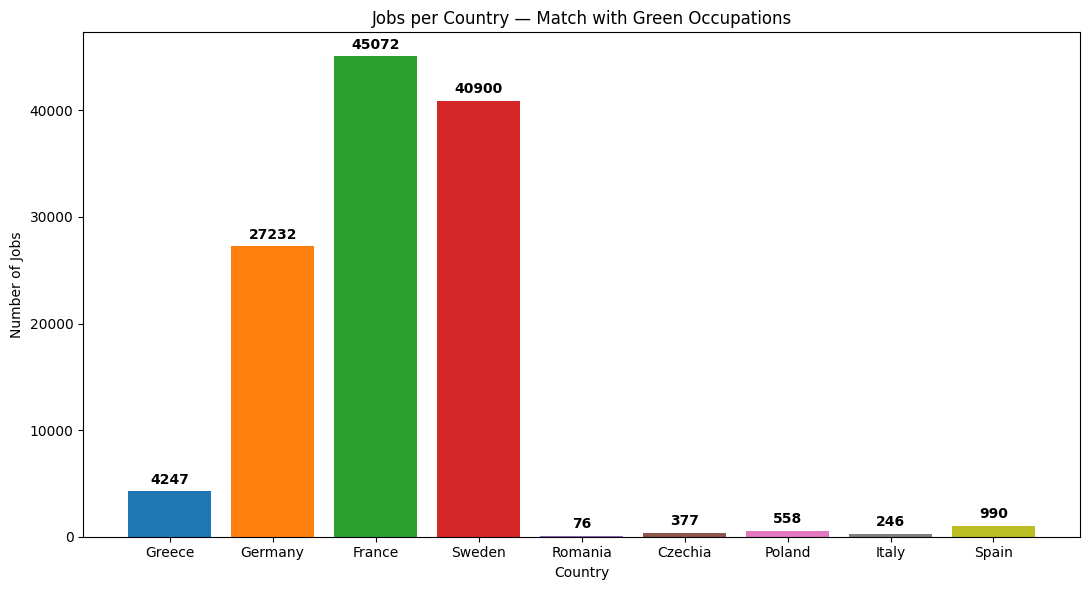

In [18]:
import json
import matplotlib.pyplot as plt

# Dictionary with file paths for each country
occupation_files = {
    "Greece":  "skillab_jobs_greece_green_occupations.json",
    "Germany": "skillab_jobs_germany_green_occupations.json",
    "France":  "skillab_jobs_france_green_occupations.json",
    "Sweden":  "skillab_jobs_sweden_green_occupations.json",
    "Romania": "skillab_jobs_romania_green_skills.json",
    "Czechia": "skillab_jobs_czechia_green_skills.json",
    "Poland":  "skillab_jobs_poland_green_final.json",
    "Italy":   "skillab_jobs_italy_green_final.json",
    "Spain":   "skillab_jobs_spain_green_final.json",
}

countries_to_plot = ["Greece", "Germany", "France", "Sweden", "Romania", "Czechia", "Poland", "Italy", "Spain"]

counts = {}
for country in countries_to_plot:
    file_path = occupation_files[country]
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    counts[country] = len(data)

# Prepare data for plotting
countries = list(counts.keys())
values = list(counts.values())

# Plot
plt.figure(figsize=(11, 6))
bars = plt.bar(countries, values, color=plt.cm.tab10.colors[:len(countries)])

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{value}",
        ha="center", va="bottom", fontweight="bold"
    )

plt.title("Jobs per Country — Match with Green Occupations")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()